<a href="https://colab.research.google.com/github/NataliiaFakas/TFG_BMW/blob/main/5_RF_Part_Temp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Predicción de ventas: comparación de enfoques y validación temporal**



---



# Introducción

A lo largo cuaderno se desarrollará la fase final del estudio de predicción de las matriculaciones de BMW mediante **Random Forest**, comparando dos formas de representar los datos.

En primer lugar, se evaluará el **Enfoque A**, basado en las ventas y variables macroeconómicas en valores absolutos. Para este estudio se utilizará una **partición temporal** (2005-2018 para entrenamiento, 2019-2021 para desarrollo y 2022-2025 para test), un **baseline naive** a diferencia del estudio anterior y una validación mediante `TimeSeriesSplit` con cuatro bloques.

Después, se desarrollará un **Enfoque B**, en el que las ventas se expresarán como **variación porcentual interanual** y las variables macroeconómicas absolutas se transformarñán en variaciones relativas. Y se repetirá el mismo proceso de partición, baseline, Random Forest y `TimeSeriesSplit`.

Finalmente, se compararán ambos enfoques mediante **MSE y RMSE** para determinar si el uso de variaciones relativas mejora la capacidad predictiva del modelo.



---
**Todo este bloque se mantiene de la misma manera que el anterior**


In [ ]:
import pandas as pd

from google.colab import drive
drive.mount('/content/drive')

ruta_macro = "/content/drive/MyDrive/TFG_BMW/datasets/bmw_dataset_variables_macro.csv"
ruta_bmw = "/content/drive/MyDrive/TFG_BMW/datasets/ventas_bmw.csv"

df_macro = pd.read_csv(ruta_macro)
df_bmw = pd.read_csv(ruta_bmw)

display(df_macro.head())
display(df_bmw.head())

Mounted at /content/drive


,Year,Unemployment_Rate,GDP_Growth,Deposit_Facility,HICP,Industrial_Production,Retail_Sales_Growth,Consumer_Confidence,Compensation_Per_Employee,Brent_Oil_Price,EUR_USD,Euribor_12M,Population_Total
0,2005,8.9,1.7,1.25,2.18,153.2,0.03,-4.2,31.22,54.57,1.2441,2.19,434585887
1,2006,8.2,3.2,2.50,2.19,147.7,0.04,-3.5,31.95,65.16,1.2556,3.08,436041018
2,2007,7.2,2.9,3.00,2.13,145.5,0.03,-2.1,32.75,72.44,1.3705,4.24,437514477
3,2008,7.1,0.4,2.00,3.30,148.0,0.01,-10.8,33.86,96.94,1.4708,4.63,439074280
4,2009,9.0,-4.4,0.25,0.29,144.5,-0.03,-21.7,34.41,61.74,1.3948,1.31,440467898


,Año,Ventas_BMW_Unidades
0,2005,1126768
1,2006,1185088
2,2007,1276793
3,2008,1202239
4,2009,1068770


# Función `variables_modelo`

---

🔧 **Reutilizaremos esta función cada vez que se entrene un nuevo modelo para incorporar al conjunto de datos de ventas de BMW**, las variables macroeconómicas seleccionadas utilizando el año como clave de unión.

In [ ]:
def añadir_variables_macro(df_bmw, df_macro):

    df_final = df_bmw.merge(
        df_macro[variables_modelo],
        on="Year",
        how="left"
    )

    return df_final

In [ ]:
variables_modelo = [
    "Year",
    "Compensation_Per_Employee",
    "Industrial_Production",
    "Population_Total",
    "EUR_USD"
]

df_macro_reducido = df_macro[variables_modelo]

df_macro_reducido.head()

,Year,Compensation_Per_Employee,Industrial_Production,Population_Total,EUR_USD
0,2005,31.22,153.2,434585887,1.2441
1,2006,31.95,147.7,436041018,1.2556
2,2007,32.75,145.5,437514477,1.3705
3,2008,33.86,148.0,439074280,1.4708
4,2009,34.41,144.5,440467898,1.3948


In [ ]:
df_bmw_filtrado = df_bmw.rename(columns={"Año": "Year"})

data = añadir_variables_macro(df_bmw_filtrado, df_macro_reducido)

display(data.head())
print("Shape del dataset definitivo:", data.shape)

,Year,Ventas_BMW_Unidades,Compensation_Per_Employee,Industrial_Production,Population_Total,EUR_USD
0,2005,1126768,31.22,153.2,434585887,1.2441
1,2006,1185088,31.95,147.7,436041018,1.2556
2,2007,1276793,32.75,145.5,437514477,1.3705
3,2008,1202239,33.86,148.0,439074280,1.4708
4,2009,1068770,34.41,144.5,440467898,1.3948


Shape del dataset definitivo: (21, 6)


In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

RANDOM_STATE = 42  # semilla fija para reproducibilidad

X = data.drop(columns=["Year", "Ventas_BMW_Unidades"])
y = data["Ventas_BMW_Unidades"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (21, 4)
y shape: (21,)




---



# PARTE 1: Eliminamos la partición aleatoria y la sustituimos por una partición temporal



---



Esto se debe a que los datos presentan una **estructura temporal**, ya que las ventas de un año están relacionadas con la evolución de los años anteriores. Por este motivo, no es adecuado mezclar aleatoriamente las observaciones, ya que esto podría introducir información del futuro en el entrenamiento.

En su lugar, se mantiene el orden cronológico y se divide el conjunto de datos de la siguiente forma:

- **Train:** 2005-2018
- **Dev:** 2019-2021
- **Test:** 2022-2025

De esta manera, el modelo se entrena únicamente con información del pasado y se evalúa posteriormente sobre años que no ha visto.

In [ ]:
# Partición temporal:
# Train: 2005-2018
# Dev:   2019-2021
# Test:  2022-2025

train = data[data["Year"] <= 2018]
dev = data[(data["Year"] >= 2019) & (data["Year"] <= 2021)]
test = data[data["Year"] >= 2022]

X_train = train.drop(columns=["Year", "Ventas_BMW_Unidades"])
y_train = train["Ventas_BMW_Unidades"]

X_dev = dev.drop(columns=["Year", "Ventas_BMW_Unidades"])
y_dev = dev["Ventas_BMW_Unidades"]

X_test = test.drop(columns=["Year", "Ventas_BMW_Unidades"])
y_test = test["Ventas_BMW_Unidades"]

print(f"Train: {len(train)} muestras ({train['Year'].min()}-{train['Year'].max()})")
print(f"Dev:   {len(dev)} muestras ({dev['Year'].min()}-{dev['Year'].max()})")
print(f"Test:  {len(test)} muestras ({test['Year'].min()}-{test['Year'].max()})")

Train: 14 muestras (2005-2018)
Dev:   3 muestras (2019-2021)
Test:  4 muestras (2022-2025)




---


# PARTE 2 — Crear el baseline naive

---

## ¿Qué es un baseline naive?

Un **baseline naive** es un modelo de referencia muy sencillo que permite establecer un punto de comparación para evaluar modelos más complejos. De esta manera se puede comparar el error cometido en cada una de las predicciones del modelo anterior.

## ¿Para qué se utilizará el baseline naive?

En este caso, se utiliza como predicción para cada año el número de matriculaciones observado en el **año anterior**. De esta forma, podremos comprobar si el Random Forest aporta una mejora real respecto a una predicción basada únicamente en la información del año anterior.

Para 2005, al no disponer de un año anterior dentro del conjunto de datos, se establece una predicción de 0.

Posteriormente, se comparará el rendimiento del baseline con el Random Forest utilizando **MSE y RMSE**.

In [ ]:
data_baseline = data.copy()

data_baseline["Prediccion_Naive"] = (
    data_baseline["Ventas_BMW_Unidades"].shift(1)
)

# Para 2005 no existe un año anterior
data_baseline.loc[
    data_baseline["Year"] == 2005,
    "Prediccion_Naive"
] = 0

display(data_baseline.head())

,Year,Ventas_BMW_Unidades,Compensation_Per_Employee,Industrial_Production,Population_Total,EUR_USD,Prediccion_Naive
0,2005,1126768,31.22,153.2,434585887,1.2441,0.0
1,2006,1185088,31.95,147.7,436041018,1.2556,1126768.0
2,2007,1276793,32.75,145.5,437514477,1.3705,1185088.0
3,2008,1202239,33.86,148.0,439074280,1.4708,1276793.0
4,2009,1068770,34.41,144.5,440467898,1.3948,1202239.0




---


# PARTE 3 — Evaluar el baseline


---



Se evalúa el **baseline naive** utilizando las métricas **MSE (Mean Squared Error)** y **RMSE (Root Mean Squared Error)** como se especificó en el apartado anterior.

La evaluación se realiza tanto sobre el conjunto de **desarrollo o dev (2019-2021)**, que se utilizará como referencia para comparar y seleccionar los modelos, como sobre el conjunto de **test (2022-2025)**, que se reserva para la evaluación final.

Estos resultados servirán como **punto de referencia** para determinar si los modelos desarrollados consiguen mejorar las predicciones realizadas simplemente utilizando las ventas del año anterior.

**Resultados:**

- **Dev:** MSE = 18.575.566.348,33 | RMSE = 136.292,21
- **Test:** MSE = 10.012.345.269,50 | RMSE = 100.061,71

El baseline obtiene un **RMSE de 100.061,71 unidades en test**, lo que indica que, en promedio, las predicciones se alejan de las ventas reales en torno a 100.062 matriculaciones.

Este resultado establece el **nivel de referencia que deberán superar los modelos Random Forest**. Por tanto, un modelo será considerado mejor que el baseline si consigue obtener valores inferiores de MSE y RMSE sobre el mismo conjunto de test.

In [ ]:
from sklearn.metrics import mean_squared_error

pred_naive_dev = data_baseline.loc[
    data_baseline["Year"].between(2019, 2021),
    "Prediccion_Naive"
]

y_naive_dev = data_baseline.loc[
    data_baseline["Year"].between(2019, 2021),
    "Ventas_BMW_Unidades"
]

mse_naive_dev = mean_squared_error(
    y_naive_dev,
    pred_naive_dev
)

rmse_naive_dev = np.sqrt(mse_naive_dev)

print(f"MSE baseline en dev: {mse_naive_dev:,.2f}")
print(f"RMSE baseline en dev: {rmse_naive_dev:,.2f}")

MSE baseline en dev: 18,575,566,348.33
RMSE baseline en dev: 136,292.21


In [ ]:
pred_naive_test = data_baseline.loc[
    data_baseline["Year"] >= 2022,
    "Prediccion_Naive"
]

y_naive_test = data_baseline.loc[
    data_baseline["Year"] >= 2022,
    "Ventas_BMW_Unidades"
]

mse_naive_test = mean_squared_error(
    y_naive_test,
    pred_naive_test
)

rmse_naive_test = np.sqrt(mse_naive_test)

print(f"MSE baseline en test: {mse_naive_test:,.2f}")
print(f"RMSE baseline en test: {rmse_naive_test:,.2f}")

MSE baseline en test: 10,012,345,269.50
RMSE baseline en test: 100,061.71




---


# PARTE 4 — Random Forest con partición temporal


---



En esta parte se entrena un modelo **Random Forest** utilizando únicamente el conjunto de entrenamiento (2005-2018) y se evalúan diferentes combinaciones de hiperparámetros sobre el conjunto de desarrollo (2019-2021).

Aquí se prueban distintos valores de:

- `n_estimators`: número de árboles que forman el bosque.
- `min_impurity_decrease`: reducción mínima de impureza necesaria para realizar una división en un árbol.

Para cada combinación se calcula el **MSE sobre el conjunto de desarrollo** y posteriormente se ordenan los resultados de menor a mayor error. De esta forma, se seleccionan los hiperparámetros que ofrecen el mejor rendimiento sin utilizar todavía el conjunto de test.

### Resultados

La mejor combinación obtenida es:

- `n_estimators = 50`
- `min_impurity_decrease = 0`
- **MSE en dev = 7.479.421.000 aproximadamente**

El resultado muestra una mejora considerable respecto al baseline naive, cuyo MSE en desarrollo era **18.575.566.348,33**. Por tanto, esta configuración del Random Forest consigue reducir el error sobre el conjunto de desarrollo y será la seleccionada para realizar posteriormente la evaluación final sobre el conjunto de test.

In [ ]:
n_estimators_grid = [10, 25, 50, 100, 200, 300]
min_impurity_decrease_grid = [0.0, 1e6, 5e6, 1e7, 5e7, 1e8]

resultados = []

for n_est in n_estimators_grid:
    for mid in min_impurity_decrease_grid:

        modelo = RandomForestRegressor(
            n_estimators=n_est,
            min_impurity_decrease=mid,
            random_state=RANDOM_STATE
        )

        modelo.fit(X_train, y_train)

        pred_dev = modelo.predict(X_dev)

        mse_dev = mean_squared_error(
            y_dev,
            pred_dev
        )

        resultados.append({
            "n_estimators": n_est,
            "min_impurity_decrease": mid,
            "MSE_dev": mse_dev
        })

df_resultados = (
    pd.DataFrame(resultados)
    .sort_values("MSE_dev")
)

display(df_resultados.head(10))

,n_estimators,min_impurity_decrease,MSE_dev
12,50,0.0,7.479421e+09
13,50,1000000.0,7.479421e+09
14,50,5000000.0,7.479421e+09
15,50,10000000.0,7.479421e+09
24,200,0.0,7.616778e+09
25,200,1000000.0,7.616778e+09
26,200,5000000.0,7.616778e+09
27,200,10000000.0,7.616778e+09
16,50,50000000.0,7.732620e+09
6,25,0.0,7.856447e+09




---
# PARTE 5 — Evaluar este Random Forest en test


---



Una vez seleccionados los mejores hiperparámetros a partir del conjunto de desarrollo, se entrena el **Random Forest final** utilizando los datos de entrenamiento (2005-2018).

A continuación, el modelo se evalúa sobre el **conjunto de test (2022-2025)**, que se ha mantenido separado durante el proceso de selección.

### Resultados

- **MSE en test:** 12.114.233.109,67
- **RMSE en test:** 110.064,68

El Random Forest obtiene un **RMSE de 110.064,68 matriculaciones**, ligeramente superior al RMSE del baseline naive (**100.061,71**). Por tanto, en esta primera evaluación el Random Forest **no mejora al baseline sobre el conjunto de test**.

Esto muestra la importancia de no seleccionar el modelo únicamente por su rendimiento en el conjunto de desarrollo, especialmente cuando se dispone de un número reducido de observaciones. Por ello, a continuación se utilizará **TimeSeriesSplit** para realizar una validación cruzada respetando la estructura temporal de los datos.


In [ ]:
mejor = df_resultados.iloc[0]

modelo_final = RandomForestRegressor(
    n_estimators=int(mejor["n_estimators"]),
    min_impurity_decrease=mejor["min_impurity_decrease"],
    random_state=RANDOM_STATE
)

modelo_final.fit(X_train, y_train)

pred_test = modelo_final.predict(X_test)

mse_test = mean_squared_error(
    y_test,
    pred_test
)

rmse_test = np.sqrt(mse_test)

print(f"MSE en test: {mse_test:,.2f}")
print(f"RMSE en test: {rmse_test:,.2f}")

MSE en test: 12,114,233,109.67
RMSE en test: 110,064.68




---

# PARTE 6 — TimeSeriesSplit

---



En esta parte se aplica **TimeSeriesSplit** para realizar una validación cruzada que respete el orden temporal de los datos.

A diferencia de una validación cruzada convencional, las observaciones utilizadas para entrenar cada modelo siempre pertenecen a años anteriores a los utilizados para su validación. De esta forma, se evita utilizar información futura durante el entrenamiento.

Se utilizan **4 bloques temporales** sobre el periodo 2005-2021:

- **Bloque 1:** Train 2005-2009 → Validación 2010-2012
- **Bloque 2:** Train 2005-2012 → Validación 2013-2015
- **Bloque 3:** Train 2005-2015 → Validación 2016-2018
- **Bloque 4:** Train 2005-2018 → Validación 2019-2021

El último bloque reproduce la partición temporal utilizada anteriormente, mientras que los bloques anteriores permiten evaluar el modelo en diferentes periodos históricos.

Esta estrategia permitirá obtener una evaluación más robusta de los hiperparámetros antes de entrenar el modelo definitivo y evaluarlo sobre el **test 2022-2025**.

In [ ]:
data_train_dev = data[
    data["Year"] <= 2021
].copy()

X_train_dev = data_train_dev.drop(
    columns=["Year", "Ventas_BMW_Unidades"]
)

y_train_dev = data_train_dev["Ventas_BMW_Unidades"]

In [ ]:
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
tscv = TimeSeriesSplit(n_splits=4)

for i, (train_idx, val_idx) in enumerate(
    tscv.split(X_train_dev),
    start=1
):

    print(f"Bloque {i}")
    print(
        "Train:",
        data_train_dev.iloc[train_idx]["Year"].min(),
        "-",
        data_train_dev.iloc[train_idx]["Year"].max()
    )

    print(
        "Validación:",
        data_train_dev.iloc[val_idx]["Year"].min(),
        "-",
        data_train_dev.iloc[val_idx]["Year"].max()
    )

    print()

Bloque 1
Train: 2005 - 2009
Validación: 2010 - 2012

Bloque 2
Train: 2005 - 2012
Validación: 2013 - 2015

Bloque 3
Train: 2005 - 2015
Validación: 2016 - 2018

Bloque 4
Train: 2005 - 2018
Validación: 2019 - 2021





---


# PARTE 8 — GridSearchCV



---



Se utiliza `GridSearchCV` junto con `TimeSeriesSplit` para seleccionar los hiperparámetros del Random Forest. De esta forma, cada combinación se evalúa mediante los cuatro bloques temporales definidos anteriormente.

La selección se realiza utilizando **RMSE**, ya que permite interpretar directamente el error en número de matriculaciones.

### Resultados

Los mejores hiperparámetros obtenidos son:

- `n_estimators = 10`
- `min_impurity_decrease = 50.000.000`
- **RMSE medio de validación = 235.573,53**

Este valor representa el error medio del modelo en los cuatro bloques de validación. Aunque el RMSE es superior al obtenido en la optimización realizada únicamente sobre el conjunto `dev`, esta validación proporciona una estimación más robusta al evaluar el modelo en diferentes periodos temporales.

Estos hiperparámetros serán utilizados para entrenar el modelo final y evaluar su rendimiento sobre el conjunto de **test (2022-2025)**.

In [ ]:
rf = RandomForestRegressor(
    random_state=RANDOM_STATE
)

In [ ]:
param_grid = {
    "n_estimators": [10, 25, 50, 100, 200, 300],
    "min_impurity_decrease": [
        0.0,
        1e6,
        5e6,
        1e7,
        5e7,
        1e8
    ]
}

In [ ]:
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

grid_search.fit(
    X_train_dev,
    y_train_dev
)

GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=4, test_size=None),
             estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'min_impurity_decrease': [0.0, 1000000.0, 5000000.0,
                                                   10000000.0, 50000000.0,
                                                   100000000.0],
                         'n_estimators': [10, 25, 50, 100, 200, 300]},
             scoring='neg_root_mean_squared_error')

In [ ]:
print("Mejores hiperparámetros:")
print(grid_search.best_params_)

print(
    "RMSE medio de validación:",
    -grid_search.best_score_
)

Mejores hiperparámetros:
{'min_impurity_decrease': 50000000.0, 'n_estimators': 10}
RMSE medio de validación: 235573.53278545538




---

# PARTE 9 — Evaluar este modelo en el mismo test


---



Una vez seleccionados los hiperparámetros mediante `GridSearchCV` y `TimeSeriesSplit`, se entrena el modelo utilizando todas las observaciones disponibles hasta 2021 y se evalúa sobre el mismo conjunto de **test (2022-2025)**.

### Resultados

- **MSE en test:** 5.513.784.700,02
- **RMSE en test:** 74.254,86

El modelo obtiene un **RMSE de 74.254,86 matriculaciones**, mejorando claramente el resultado del baseline naive, que alcanzaba un RMSE de **100.061,71**.

Además, también mejora respecto al Random Forest seleccionado únicamente mediante la partición temporal, cuyo RMSE era de **110.064,68**. Esto indica que la validación mediante `TimeSeriesSplit` permite seleccionar una configuración con una mejor capacidad de generalización sobre el periodo de test.

Por tanto, este modelo será el **Random Forest de referencia del Enfoque A** para compararlo posteriormente con el enfoque basado en variaciones relativas.

In [ ]:
modelo_cv = grid_search.best_estimator_

modelo_cv.fit(
    X_train_dev,
    y_train_dev
)

pred_test_cv = modelo_cv.predict(X_test)

mse_test_cv = mean_squared_error(
    y_test,
    pred_test_cv
)

rmse_test_cv = np.sqrt(mse_test_cv)

print(f"MSE en test: {mse_test_cv:,.2f}")
print(f"RMSE en test: {rmse_test_cv:,.2f}")

MSE en test: 5,513,784,700.02
RMSE en test: 74,254.86




---


# PARTE 10 — Comparación



---



Se comparan los resultados obtenidos por el **baseline naive** y las dos configuraciones de Random Forest: una seleccionada mediante la partición temporal y otra mediante `TimeSeriesSplit`.

### Resultados

| Modelo | MSE dev | RMSE dev | MSE test | RMSE test |
|---|---:|---:|---:|---:|
| Baseline naive | 18.575.566.348,33 | 136.292,21 | 10.012.345.269,50 | 100.061,71 |
| Random Forest - partición temporal | 7.479.421.000 aprox. | 86.483,65 | 12.114.233.109,67 | 110.064,68 |
| Random Forest - TimeSeriesSplit | 55.494.890.000 aprox. | 235.573,53 | 5.513.784.700,02 | 74.254,86 |

Como se puede observar, el Random Forest seleccionado mediante la **partición temporal** obtiene mejores resultados en `dev`, pero no consigue superar al baseline en `test`. En cambio, el modelo seleccionado mediante **TimeSeriesSplit** presenta un mayor error medio de validación, pero obtiene el mejor resultado sobre el conjunto de test.

En concreto, el Random Forest con `TimeSeriesSplit` reduce el **RMSE de 100.061,71 a 74.254,86 matriculaciones** respecto al baseline. Por tanto, esta configuración es la que ofrece el mejor rendimiento final dentro del **Enfoque A**.

In [ ]:
comparacion_final_abs_completa = pd.DataFrame({
    "Modelo": [
        "Baseline naive",
        "Random Forest - partición temporal",
        "Random Forest - TimeSeriesSplit"
    ],
    "MSE_dev": [
        mse_naive_dev,
        mejor["MSE_dev"],
        (-grid_search.best_score_) ** 2  # RMSE positivo al cuadrado = MSE
    ],
    "RMSE_dev": [
        rmse_naive_dev,
        np.sqrt(mejor["MSE_dev"]),
        -grid_search.best_score_
    ],
    "MSE_test": [mse_naive_test, mse_test, mse_test_cv],
    "RMSE_test": [rmse_naive_test, rmse_test, rmse_test_cv]
})

display(comparacion_final_abs_completa)

,Modelo,MSE_dev,RMSE_dev,MSE_test,RMSE_test
0,Baseline naive,1.857557e+10,136292.209419,1.001235e+10,100061.707309
1,Random Forest - partición temporal,7.479421e+09,86483.647868,1.211423e+10,110064.676939
2,Random Forest - TimeSeriesSplit,5.549489e+10,235573.532785,5.513785e+09,74254.863141




---


# PARTE 11 — Partición temporal del dataset de variaciones


---



En este segundo enfoque, la variable objetivo se transforma en la **variación porcentual interanual de las matriculaciones de BMW**. Del mismo modo, las variables macroeconómicas expresadas en valores absolutos se transforman en variaciones respecto al año anterior.

Al calcular estas variaciones no es posible obtener un valor para 2005, por lo que este año se elimina del conjunto de datos. Se mantienen así **20 observaciones, correspondientes al periodo 2006-2025**.

La partición temporal mantiene los mismos periodos utilizados en el Enfoque A, para garantizar la comparabilidad entre ambos enfoques:

- **Train:** 2006-2018 → 13 observaciones
- **Dev:** 2019-2021 → 3 observaciones
- **Test:** 2022-2025 → 4 observaciones

De esta forma, se mantiene el orden cronológico y se reserva el mismo periodo de test para poder comparar posteriormente los resultados de ambos enfoques.

In [ ]:
data_var = data.copy()

# Variación porcentual de las ventas de BMW
data_var["Ventas_BMW_Variacion"] = (
    data_var["Ventas_BMW_Unidades"].pct_change()
)

# Variables absolutas que pasan a variaciones relativas
variables_variacion = [
    "Compensation_Per_Employee",
    "Industrial_Production",
    "Population_Total",
    "EUR_USD"
]

# Calcular las variaciones respecto al año anterior
for variable in variables_variacion:
    data_var[variable + "_Variacion"] = (
        data_var[variable].pct_change()
    )

# Eliminar únicamente 2005
data_var = data_var.dropna(
    subset=[
        "Ventas_BMW_Variacion",
        "Compensation_Per_Employee_Variacion",
        "Industrial_Production_Variacion",
        "Population_Total_Variacion",
        "EUR_USD_Variacion"
    ]
)

display(data_var.head())

print("Shape:", data_var.shape)

,Year,Ventas_BMW_Unidades,Compensation_Per_Employee,Industrial_Production,Population_Total,EUR_USD,Ventas_BMW_Variacion,Compensation_Per_Employee_Variacion,Industrial_Production_Variacion,Population_Total_Variacion,EUR_USD_Variacion
1,2006,1185088,31.95,147.7,436041018,1.2556,0.051759,0.023382,-0.035901,0.003348,0.009244
2,2007,1276793,32.75,145.5,437514477,1.3705,0.077382,0.025039,-0.014895,0.003379,0.091510
3,2008,1202239,33.86,148.0,439074280,1.4708,-0.058392,0.033893,0.017182,0.003565,0.073185
4,2009,1068770,34.41,144.5,440467898,1.3948,-0.111017,0.016243,-0.023649,0.003174,-0.051673
5,2010,1224280,35.20,127.2,441160594,1.3257,0.145504,0.022958,-0.119723,0.001573,-0.049541


Shape: (20, 11)


In [ ]:
train_var = data_var[
    data_var["Year"] <= 2018
].copy()

dev_var = data_var[
    (data_var["Year"] >= 2019) &
    (data_var["Year"] <= 2021)
].copy()

test_var = data_var[
    data_var["Year"] >= 2022
].copy()

print(
    f"Train: {len(train_var)} muestras "
    f"({train_var['Year'].min()}-{train_var['Year'].max()})"
)

print(
    f"Dev:   {len(dev_var)} muestras "
    f"({dev_var['Year'].min()}-{dev_var['Year'].max()})"
)

print(
    f"Test:  {len(test_var)} muestras "
    f"({test_var['Year'].min()}-{test_var['Year'].max()})"
)

Train: 13 muestras (2006-2018)
Dev:   3 muestras (2019-2021)
Test:  4 muestras (2022-2025)




---


# PARTE 12 — Crear X e y para cada conjunto



---


Se separan las **variables predictoras (`X`)** de la **variable objetivo (`y`)** para cada uno de los conjuntos.

La variable objetivo será `Ventas_BMW_Variacion`, mientras que las cuatro variables macroeconómicas utilizadas como predictores se expresan también como variaciones interanuales.

El resultado es:

- **Train:** 13 observaciones y 4 variables predictoras.
- **Dev:** 3 observaciones y 4 variables predictoras.
- **Test:** 4 observaciones y 4 variables predictoras.

De esta forma, se mantiene la misma estructura de variables utilizada posteriormente para entrenar y evaluar el Random Forest.

In [ ]:
variables_X_var = [
    "Compensation_Per_Employee_Variacion",
    "Industrial_Production_Variacion",
    "Population_Total_Variacion",
    "EUR_USD_Variacion"
]

X_train_var = train_var[variables_X_var]
y_train_var = train_var["Ventas_BMW_Variacion"]

X_dev_var = dev_var[variables_X_var]
y_dev_var = dev_var["Ventas_BMW_Variacion"]

X_test_var = test_var[variables_X_var]
y_test_var = test_var["Ventas_BMW_Variacion"]

print("X_train:", X_train_var.shape)
print("y_train:", y_train_var.shape)

print("X_dev:", X_dev_var.shape)
print("y_dev:", y_dev_var.shape)

print("X_test:", X_test_var.shape)
print("y_test:", y_test_var.shape)

X_train: (13, 4)
y_train: (13,)
X_dev: (3, 4)
y_dev: (3,)
X_test: (4, 4)
y_test: (4,)




---


# PARTE 13 — Crear el baseline naive para las variaciones



---

En este enfoque, el **baseline naive** se adapta a la nueva variable objetivo. ya que, en lugar de utilizar las ventas del año anterior directamente, se utiliza como predicción, la **variación porcentual de las ventas observada en el año anterior**.

Este baseline servirá nuevamente como **modelo de referencia**, permitiendo comprobar si el Random Forest consigue mejorar la predicción de las variaciones interanuales utilizando las variables macroeconómicas.

**Es importante denotar que para 2006 no existe una variación del año anterior dentro del nuevo dataset, por lo que su predicción queda como `NaN` y no se utilizará en la evaluación.**

In [ ]:
data_baseline_var = data_var.copy()

# Predicción naive:
# la variación del año siguiente se estima igual a
# la variación observada en el año anterior

data_baseline_var["Prediccion_Naive_Variacion"] = (
    data_baseline_var["Ventas_BMW_Variacion"].shift(1)
)

display(data_baseline_var.head())

,Year,Ventas_BMW_Unidades,Compensation_Per_Employee,Industrial_Production,Population_Total,EUR_USD,Ventas_BMW_Variacion,Compensation_Per_Employee_Variacion,Industrial_Production_Variacion,Population_Total_Variacion,EUR_USD_Variacion,Prediccion_Naive_Variacion
1,2006,1185088,31.95,147.7,436041018,1.2556,0.051759,0.023382,-0.035901,0.003348,0.009244,NaN
2,2007,1276793,32.75,145.5,437514477,1.3705,0.077382,0.025039,-0.014895,0.003379,0.091510,0.051759
3,2008,1202239,33.86,148.0,439074280,1.4708,-0.058392,0.033893,0.017182,0.003565,0.073185,0.077382
4,2009,1068770,34.41,144.5,440467898,1.3948,-0.111017,0.016243,-0.023649,0.003174,-0.051673,-0.058392
5,2010,1224280,35.20,127.2,441160594,1.3257,0.145504,0.022958,-0.119723,0.001573,-0.049541,-0.111017


---
# PARTE 14 — Evaluar el baseline en dev


---



Se evalúa el baseline naive sobre el conjunto de **desarrollo (2019-2021)** utilizando las métricas **MSE** y **RMSE**.

### Resultados

- **MSE:** 0,010495
- **RMSE:** 0,102447

El baseline presenta un **RMSE de 0,102447**, es decir, un error aproximado de **10,24 puntos porcentuales** en la predicción de la variación interanual de las matriculaciones.

Este resultado se utilizará como referencia para comprobar si el **Random Forest** consigue mejorar la predicción de las variaciones utilizando las variables macroeconómicas.

In [ ]:
pred_naive_var_dev = data_baseline_var.loc[
    data_baseline_var["Year"].between(2019, 2021),
    "Prediccion_Naive_Variacion"
]

y_naive_var_dev = data_baseline_var.loc[
    data_baseline_var["Year"].between(2019, 2021),
    "Ventas_BMW_Variacion"
]

mse_naive_var_dev = mean_squared_error(
    y_naive_var_dev,
    pred_naive_var_dev
)

rmse_naive_var_dev = np.sqrt(
    mse_naive_var_dev
)

print(
    f"MSE baseline variaciones en dev: "
    f"{mse_naive_var_dev:,.6f}"
)

print(
    f"RMSE baseline variaciones en dev: "
    f"{rmse_naive_var_dev:,.6f}"
)

MSE baseline variaciones en dev: 0.010495
RMSE baseline variaciones en dev: 0.102447




---


# PARTE 15 — Evaluar el baseline en test



---



### Resultados

- **MSE:** 0,011272
- **RMSE:** 0,106172

El baseline obtiene un **RMSE de 0,106172**, equivalente a un error aproximado de **10,62 puntos porcentuales** en la predicción de la variación interanual de las matriculaciones.

Este resultado establece el último punto de referencia para evaluar si el Random Forest consigue mejorar la predicción de las variaciones relativas sobre el periodo de test.


In [ ]:
pred_naive_var_test = data_baseline_var.loc[
    data_baseline_var["Year"] >= 2022,
    "Prediccion_Naive_Variacion"
]

y_naive_var_test = data_baseline_var.loc[
    data_baseline_var["Year"] >= 2022,
    "Ventas_BMW_Variacion"
]

mse_naive_var_test = mean_squared_error(
    y_naive_var_test,
    pred_naive_var_test
)

rmse_naive_var_test = np.sqrt(
    mse_naive_var_test
)

print(
    f"MSE baseline variaciones en test: "
    f"{mse_naive_var_test:,.6f}"
)

print(
    f"RMSE baseline variaciones en test: "
    f"{rmse_naive_var_test:,.6f}"
)

MSE baseline variaciones en test: 0.011272
RMSE baseline variaciones en test: 0.106172


# PARTE 16 — Random Forest con partición temporal

In [ ]:
n_estimators_grid_var = [
    10, 25, 50, 100, 200, 300
]

min_impurity_decrease_grid_var = [
    0.0,
    0.0001,
    0.0005,
    0.001,
    0.005,
    0.01
]



---


# PARTE 17 — Optimización de hiperparámetros


---



Se prueban distintas combinaciones de `n_estimators` y `min_impurity_decrease` para seleccionar la configuración con menor **MSE en el conjunto de desarrollo**.

La mejor combinación es **10 árboles** y `min_impurity_decrease = 0,01`, con un **MSE de 0,004601**.

In [ ]:
resultados_var = []

for n_est in n_estimators_grid_var:

    for mid in min_impurity_decrease_grid_var:

        modelo = RandomForestRegressor(
            n_estimators=n_est,
            min_impurity_decrease=mid,
            random_state=RANDOM_STATE
        )

        modelo.fit(
            X_train_var,
            y_train_var
        )

        pred_dev_var = modelo.predict(
            X_dev_var
        )

        mse_dev_var = mean_squared_error(
            y_dev_var,
            pred_dev_var
        )

        resultados_var.append({
            "n_estimators": n_est,
            "min_impurity_decrease": mid,
            "MSE_dev": mse_dev_var
        })

df_resultados_var = (
    pd.DataFrame(resultados_var)
    .sort_values("MSE_dev")
)

display(
    df_resultados_var.head(10)
)

,n_estimators,min_impurity_decrease,MSE_dev
5,10,0.010,0.004601
11,25,0.010,0.005159
4,10,0.005,0.005183
0,10,0.000,0.005198
17,50,0.010,0.005414
35,300,0.010,0.005450
30,300,0.000,0.005470
29,200,0.010,0.005484
23,100,0.010,0.005490
10,25,0.005,0.005567




---


# PARTE 18 — Seleccionar los mejores hiperparámetros



---



Como se puede observar, la combinación que obtiene el menor error en el conjunto de desarrollo es:

- **`n_estimators` = 10**
- **`min_impurity_decrease` = 0,01**
- **MSE en dev = 0,004601**

In [ ]:
mejor_var = df_resultados_var.iloc[0]

print("Mejores hiperparámetros:")

print(
    f"n_estimators = "
    f"{int(mejor_var['n_estimators'])}"
)

print(
    f"min_impurity_decrease = "
    f"{mejor_var['min_impurity_decrease']}"
)

print(
    f"MSE en dev = "
    f"{mejor_var['MSE_dev']:,.6f}"
)

Mejores hiperparámetros:
n_estimators = 10
min_impurity_decrease = 0.01
MSE en dev = 0.004601




---


# PARTE 19 — Evaluar Random Forest en test


---



El modelo seleccionado se evalúa sobre el conjunto de **test (2022-2025)**, que no ha sido utilizado durante el entrenamiento ni durante la selección de hiperparámetros.

Los resultados obtenidos han sido:

- **MSE en test:** 0,004011
- **RMSE en test:** 0,063330

El error obtenido es inferior al del baseline naive, lo que indica que el Random Forest mejora la capacidad de predicción de las variaciones interanuales de las ventas.

In [ ]:
modelo_final_var = RandomForestRegressor(
    n_estimators=int(
        mejor_var["n_estimators"]
    ),
    min_impurity_decrease=(
        mejor_var["min_impurity_decrease"]
    ),
    random_state=RANDOM_STATE
)

modelo_final_var.fit(
    X_train_var,
    y_train_var
)

pred_test_var = modelo_final_var.predict(
    X_test_var
)

mse_test_var = mean_squared_error(
    y_test_var,
    pred_test_var
)

rmse_test_var = np.sqrt(
    mse_test_var
)

print(
    f"MSE Random Forest en test: "
    f"{mse_test_var:,.6f}"
)

print(
    f"RMSE Random Forest en test: "
    f"{rmse_test_var:,.6f}"
)

MSE Random Forest en test: 0.004011
RMSE Random Forest en test: 0.063330




---


# PARTE 20 — Comparación del enfoque B con el baseline


---



Se comparan los resultados del **Random Forest** con los obtenidos mediante el **baseline naive**, tanto en el conjunto de desarrollo como en el conjunto de test.

El Random Forest obtiene menores valores de MSE y RMSE en ambos conjuntos, mostrando una mejora respecto al baseline.

| Modelo | MSE dev | RMSE dev | MSE test | RMSE test |
|---|---:|---:|---:|---:|
| Baseline naive | 0,010495 | 0,102447 | 0,011272 | 0,106172 |
| Random Forest | 0,004601 | 0,067830 | 0,004011 | 0,063330 |



In [ ]:
comparacion_var = pd.DataFrame({
    "Modelo": [
        "Baseline naive",
        "Random Forest"
    ],
    "MSE_dev": [
        mse_naive_var_dev,
        mejor_var["MSE_dev"]
    ],
    "RMSE_dev": [
        rmse_naive_var_dev,
        np.sqrt(mejor_var["MSE_dev"])
    ],
    "MSE_test": [
        mse_naive_var_test,
        mse_test_var
    ],
    "RMSE_test": [
        rmse_naive_var_test,
        rmse_test_var
    ]
})

display(comparacion_var)

,Modelo,MSE_dev,RMSE_dev,MSE_test,RMSE_test
0,Baseline naive,0.010495,0.102447,0.011272,0.106172
1,Random Forest,0.004601,0.067830,0.004011,0.063330




---


# PARTE 21 — TimeSeriesSplit


---



Se combinan los conjuntos de **train y dev (2006-2021)** para realizar una validación cruzada temporal mediante `TimeSeriesSplit`, manteniendo siempre el orden cronológico de las observaciones.

En total, se dispone de **16 observaciones** para el proceso de validación.

In [ ]:
data_train_dev_var = data_var[
    data_var["Year"] <= 2021
].copy()

X_train_dev_var = data_train_dev_var[
    variables_X_var
]

y_train_dev_var = data_train_dev_var[
    "Ventas_BMW_Variacion"
]

print(
    "Observaciones train + dev:",
    len(data_train_dev_var)
)

Observaciones train + dev: 16


---

# PARTE 22 — Crear TimeSeriesSplit de 4 bloques

---
Se utiliza `TimeSeriesSplit` con **4 bloques**, manteniendo el orden temporal de los datos. En cada bloque, el conjunto de entrenamiento incorpora las observaciones anteriores y la validación se realiza sobre los años siguientes.

- **Bloque 1:** Train 2006-2009 → Validación 2010-2012
- **Bloque 2:** Train 2006-2012 → Validación 2013-2015
- **Bloque 3:** Train 2006-2015 → Validación 2016-2018
- **Bloque 4:** Train 2006-2018 → Validación 2019-2021

Esta metodología permite evaluar el modelo respetando la naturaleza temporal de los datos y evitando utilizar información futura para predecir el pasado.

In [ ]:
from sklearn.model_selection import TimeSeriesSplit

tscv_var = TimeSeriesSplit(
    n_splits=4
)

for i, (train_idx, val_idx) in enumerate(
    tscv_var.split(X_train_dev_var),
    start=1
):

    print(f"Bloque {i}")

    print(
        "Train:",
        data_train_dev_var.iloc[
            train_idx
        ]["Year"].min(),
        "-",
        data_train_dev_var.iloc[
            train_idx
        ]["Year"].max()
    )

    print(
        "Validación:",
        data_train_dev_var.iloc[
            val_idx
        ]["Year"].min(),
        "-",
        data_train_dev_var.iloc[
            val_idx
        ]["Year"].max()
    )

    print()

Bloque 1
Train: 2006 - 2009
Validación: 2010 - 2012

Bloque 2
Train: 2006 - 2012
Validación: 2013 - 2015

Bloque 3
Train: 2006 - 2015
Validación: 2016 - 2018

Bloque 4
Train: 2006 - 2018
Validación: 2019 - 2021



---

# PARTE 23 — GridSearchCV con TimeSeriesSplit

---

Se utiliza `GridSearchCV` junto con `TimeSeriesSplit` para seleccionar los mejores hiperparámetros del **Random Forest**, realizando la validación de forma temporal.

De este modo, cada combinación de hiperparámetros se evalúa en los distintos bloques temporales definidos anteriormente, evitando la mezcla de observaciones futuras con pasadas.

In [ ]:
from sklearn.model_selection import GridSearchCV

rf_var = RandomForestRegressor(
    random_state=RANDOM_STATE
)

param_grid_var = {
    "n_estimators": [
        10, 25, 50, 100, 200, 300
    ],

    "min_impurity_decrease": [
        0.0,
        0.0001,
        0.0005,
        0.001,
        0.005,
        0.01
    ]
}

In [ ]:
grid_search_var = GridSearchCV(
    estimator=rf_var,
    param_grid=param_grid_var,
    cv=tscv_var,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

grid_search_var.fit(
    X_train_dev_var,
    y_train_dev_var
)

GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=4, test_size=None),
             estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'min_impurity_decrease': [0.0, 0.0001, 0.0005, 0.001,
                                                   0.005, 0.01],
                         'n_estimators': [10, 25, 50, 100, 200, 300]},
             scoring='neg_root_mean_squared_error')



---


# PARTE 24 — Obtener los mejores hiperparámetros


---



El `GridSearchCV`, utilizando `TimeSeriesSplit`, selecciona como mejor combinación:

- **`n_estimators` = 25**
- **`min_impurity_decrease` = 0,01**
- **RMSE medio de validación = 0,062664**

El modelo presenta un error medio de aproximadamente **6,27 puntos porcentuales** en la predicción de las variaciones de las ventas durante los distintos bloques de validación.

In [ ]:
print("Mejores hiperparámetros:")

print(
    grid_search_var.best_params_
)

print(
    "RMSE medio de validación:",
    -grid_search_var.best_score_
)

Mejores hiperparámetros:
{'min_impurity_decrease': 0.01, 'n_estimators': 25}
RMSE medio de validación: 0.06266359510853145




---


# PARTE 25 — Evaluar el modelo CV en el mismo test


---

Una vez seleccionados los hiperparámetros mediante `GridSearchCV` y `TimeSeriesSplit`, se evalúa el modelo sobre el mismo conjunto de **test (2022-2025)**.

Los resultados obtenidos son:

- **MSE en test:** 0,004369
- **RMSE en test:** 0,066101

El modelo mantiene un buen rendimiento sobre el conjunto de test, aunque presenta un error ligeramente superior al Random Forest seleccionado mediante la partición temporal, cuyo RMSE fue de **0,063330**.

Aun así, el modelo con `TimeSeriesSplit` mejora claramente respecto al **baseline naive**, cuyo RMSE en test fue de **0,106172**.


In [ ]:
modelo_cv_var = (
    grid_search_var.best_estimator_
)

modelo_cv_var.fit(
    X_train_dev_var,
    y_train_dev_var
)

pred_test_cv_var = (
    modelo_cv_var.predict(X_test_var)
)

mse_test_cv_var = mean_squared_error(
    y_test_var,
    pred_test_cv_var
)

rmse_test_cv_var = np.sqrt(
    mse_test_cv_var
)

print(
    f"MSE Random Forest CV en test: "
    f"{mse_test_cv_var:,.6f}"
)

print(
    f"RMSE Random Forest CV en test: "
    f"{rmse_test_cv_var:,.6f}"
)

MSE Random Forest CV en test: 0.004369
RMSE Random Forest CV en test: 0.066101




---

# PARTE 26 — Comparación final del enfoque B

---


Se comparan los resultados obtenidos en el conjunto de **test (2022-2025)** para el baseline naive y las dos configuraciones de Random Forest.

| Modelo | MSE test | RMSE test |
|---|---:|---:|
| Baseline naive | 0,011272 | 0,106172 |
| Random Forest - partición temporal | 0,004011 | 0,063330 |
| Random Forest - TimeSeriesSplit | 0,004369 | 0,066101 |

Ambos modelos de Random Forest mejoran claramente al baseline naive. El modelo con **partición temporal** obtiene el mejor resultado, con un **RMSE de 0,063330**, mientras que `TimeSeriesSplit` obtiene un RMSE de **0,066101**.

Aunque la validación cruzada temporal presenta un rendimiento ligeramente inferior en test, proporciona una selección de hiperparámetros basada en varios periodos temporales, ofreciendo una evaluación más robusta de la capacidad de generalización del modelo.

In [ ]:
comparacion_final_var = pd.DataFrame({
    "Modelo": [
        "Baseline naive",
        "Random Forest - partición estática",
        "Random Forest - TimeSeriesSplit"
    ],

    "MSE_test": [
        mse_naive_var_test,
        mse_test_var,
        mse_test_cv_var
    ],

    "RMSE_test": [
        rmse_naive_var_test,
        rmse_test_var,
        rmse_test_cv_var
    ]
})

display(comparacion_final_var)

,Modelo,MSE_test,RMSE_test
0,Baseline naive,0.011272,0.106172
1,Random Forest - partición estática,0.004011,0.063330
2,Random Forest - TimeSeriesSplit,0.004369,0.066101


---
# PARTE 27 — Comparación entre los dos enfoques
---

Finalmente, se comparan los resultados obtenidos mediante los dos enfoques planteados:

- **Enfoque A:** predicción de las ventas en valores absolutos.
- **Enfoque B:** predicción de las variaciones porcentuales de las ventas.

| Enfoque | Modelo | MSE test | RMSE test |
|---|---|---:|---:|
| A - Valores absolutos | Baseline naive | 10.012.345.269,50 | 100.061,71 |
| A - Valores absolutos | Random Forest - partición temporal | 12.114.233.109,67 | 110.064,68 |
| A - Valores absolutos | Random Forest - TimeSeriesSplit | 5.513.784.700,02 | **74.254,86** |
| B - Variaciones relativas | Baseline naive | 0,011272 | 0,106172 |
| B - Variaciones relativas | Random Forest - partición temporal | 0,004011 | **0,063330** |
| B - Variaciones relativas | Random Forest - TimeSeriesSplit | 0,004369 | 0,066101 |

En el **Enfoque A**, el mejor resultado corresponde al Random Forest con `TimeSeriesSplit`, con un RMSE de **74.254,86 matriculaciones**.

En el **Enfoque B**, el mejor resultado corresponde al Random Forest con partición temporal, con un RMSE de **0,063330**.

Por tanto, ambos enfoques permiten mejorar el baseline naive, aunque miden el error en escalas diferentes y sus RMSE **no pueden compararse directamente entre sí**. Para determinar qué enfoque resulta más adecuado para la predicción final de las ventas, será necesario analizar también las ventas reconstruidas a partir de las variaciones predichas.


In [ ]:
comparacion_enfoques = pd.DataFrame({
    "Enfoque": [
        "A - Valores absolutos",
        "A - Valores absolutos",
        "A - Valores absolutos",
        "B - Variaciones relativas",
        "B - Variaciones relativas",
        "B - Variaciones relativas"
    ],

    "Modelo": [
        "Baseline naive",
        "Random Forest - partición temporal",
        "Random Forest - TimeSeriesSplit",
        "Baseline naive",
        "Random Forest - partición temporal",
        "Random Forest - TimeSeriesSplit"
    ],

    "MSE_test": [
        mse_naive_test,
        mse_test,
        mse_test_cv,
        mse_naive_var_test,
        mse_test_var,
        mse_test_cv_var
    ],

    "RMSE_test": [
        rmse_naive_test,
        rmse_test,
        rmse_test_cv,
        rmse_naive_var_test,
        rmse_test_var,
        rmse_test_cv_var
    ]
})

display(comparacion_enfoques)

,Enfoque,Modelo,MSE_test,RMSE_test
0,A - Valores absolutos,Baseline naive,1.001235e+10,100061.707309
1,A - Valores absolutos,Random Forest - partición temporal,1.211423e+10,110064.676939
2,A - Valores absolutos,Random Forest - TimeSeriesSplit,5.513785e+09,74254.863141
3,B - Variaciones relativas,Baseline naive,1.127242e-02,0.106172
4,B - Variaciones relativas,Random Forest - partición temporal,4.010696e-03,0.063330
5,B - Variaciones relativas,Random Forest - TimeSeriesSplit,4.369295e-03,0.066101




---


# PARTE 28 — Mejora respecto al baseline


---



Se calcula la mejora de los modelos Random Forest respecto al **baseline naive**, utilizando la reducción porcentual del MSE y del RMSE en el conjunto de test.

**Enfoque A — Valores absolutos**

- **Reducción del MSE:** 44,93 %
- **Reducción del RMSE:** 25,79 %

El Random Forest con `TimeSeriesSplit` reduce el error respecto al baseline, obteniendo una mejora especialmente relevante en términos de RMSE.

**Enfoque B — Variaciones relativas**

- **Reducción del MSE:** 61,24 %
- **Reducción del RMSE:** 37,74 %

En este caso, la mejora respecto al baseline es mayor, especialmente en términos de RMSE. Esto indica que el enfoque basado en **variaciones relativas** consigue una mejora más significativa frente al modelo de referencia.

Enfoque A

In [ ]:
mejora_abs = (
    (mse_naive_test - mse_test_cv) /
    mse_naive_test
) * 100

print(f"Mejora del RF con TimeSeriesSplit frente al baseline: {mejora_abs:.2f}%")

Mejora del RF con TimeSeriesSplit frente al baseline: 44.93%


In [ ]:
mejora_rmse_abs = (
    (rmse_naive_test - rmse_test_cv) /
    rmse_naive_test
) * 100

print(
    f"Reducción del RMSE: "
    f"{mejora_rmse_abs:.2f}%"
)

Reducción del RMSE: 25.79%


Enfoque B

In [ ]:
mejora_var = (
    (mse_naive_var_test - mse_test_cv_var) /
    mse_naive_var_test
) * 100

mejora_rmse_var = (
    (rmse_naive_var_test - rmse_test_cv_var) /
    rmse_naive_var_test
) * 100

print(
    f"Reducción del MSE: {mejora_var:.2f}%"
)

print(
    f"Reducción del RMSE: {mejora_rmse_var:.2f}%"
)

Reducción del MSE: 61.24%
Reducción del RMSE: 37.74%




---

# PARTE 29 — Tabla final de resultados


---



La siguiente tabla resume los resultados obtenidos en el conjunto de test para los dos enfoques analizados: valores absolutos y variaciones relativas.

| Enfoque | Modelo | MSE test | RMSE test |
|---|---|---:|---:|
| A - Valores absolutos | Baseline naive | 10.012.345.269,50 | 100.061,71 |
| A - Valores absolutos | Random Forest - partición temporal | 12.114.233.109,67 | 110.064,68 |
| A - Valores absolutos | Random Forest - TimeSeriesSplit | 5.513.784.700,02 | 74.254,86 |
| B - Variaciones relativas | Baseline naive | 0,011272 | 0,106172 |
| B - Variaciones relativas | Random Forest - partición temporal | 0,004011 | 0,063330 |
| B - Variaciones relativas | Random Forest - TimeSeriesSplit | 0,004369 | 0,066101 |

Los resultados muestran que el **Random Forest con TimeSeriesSplit** obtiene el mejor rendimiento dentro del enfoque A, mientras que en el enfoque B el mejor resultado corresponde al Random Forest con partición temporal. En términos de mejora respecto al baseline, el **enfoque B basado en variaciones relativas** presenta una reducción del error más elevada.

In [ ]:
tabla_resultados = pd.DataFrame({
    "Enfoque": [
        "A - Valores absolutos",
        "A - Valores absolutos",
        "A - Valores absolutos",
        "B - Variaciones relativas",
        "B - Variaciones relativas",
        "B - Variaciones relativas"
    ],
    "Modelo": [
        "Baseline naive",
        "Random Forest - partición temporal",
        "Random Forest - TimeSeriesSplit",
        "Baseline naive",
        "Random Forest - partición temporal",
        "Random Forest - TimeSeriesSplit"
    ],
    "MSE_test": [
        mse_naive_test,
        mse_test,
        mse_test_cv,
        mse_naive_var_test,
        mse_test_var,
        mse_test_cv_var
    ],
    "RMSE_test": [
        rmse_naive_test,
        rmse_test,
        rmse_test_cv,
        rmse_naive_var_test,
        rmse_test_var,
        rmse_test_cv_var
    ]
})

display(tabla_resultados)

,Enfoque,Modelo,MSE_test,RMSE_test
0,A - Valores absolutos,Baseline naive,1.001235e+10,100061.707309
1,A - Valores absolutos,Random Forest - partición temporal,1.211423e+10,110064.676939
2,A - Valores absolutos,Random Forest - TimeSeriesSplit,5.513785e+09,74254.863141
3,B - Variaciones relativas,Baseline naive,1.127242e-02,0.106172
4,B - Variaciones relativas,Random Forest - partición temporal,4.010696e-03,0.063330
5,B - Variaciones relativas,Random Forest - TimeSeriesSplit,4.369295e-03,0.066101


## Predicciones del Random Forest

La siguiente tabla muestra las predicciones del Random Forest con `TimeSeriesSplit` para el periodo de test (2022-2025), junto con el error cometido en cada año.

| Año | Ventas reales | Predicción RF | Error | Error absoluto |
|---:|---:|---:|---:|---:|
| 2022 | 2.100.692 | 2.154.467,95 | -53.775,95 | 53.775,95 |
| 2023 | 2.253.835 | 2.135.954,35 | 117.880,65 | 117.880,65 |
| 2024 | 2.200.177 | 2.135.954,35 | 64.222,65 | 64.222,65 |
| 2025 | 2.169.761 | 2.135.954,35 | 33.806,65 | 33.806,65 |

El modelo presenta su mayor error en **2023**, mientras que la predicción más cercana corresponde a **2025**. En general, las predicciones se mantienen relativamente próximas a las ventas reales durante el periodo de test.

---

# PARTE 30 — Reconstrucción de las ventas mediante las variaciones predichas


---



Para interpretar las predicciones del enfoque de variaciones relativas en términos de matriculaciones, se reconstruyen las ventas a partir de la variación predicha y las ventas reales del año anterior.

| Año | Ventas reales | Variación real | Variación predicha | Ventas año anterior | Ventas predichas |
|---:|---:|---:|---:|---:|---:|
| 2022 | 2.100.692 | -5,11 % | 4,31 % | 2.213.795 | 2.309.211 |
| 2023 | 2.253.835 | 7,29 % | 4,31 % | 2.100.692 | 2.191.234 |
| 2024 | 2.200.177 | -2,38 % | 4,31 % | 2.253.835 | 2.350.977 |
| 2025 | 2.169.761 | -1,38 % | 4,31 % | 2.200.177 | 2.295.006 |

Se observa que el modelo predice una variación positiva constante del **4,31 %** para todos los años del periodo de test. Esto provoca que las ventas reconstruidas se sitúen por encima de las reales en 2022 y 2024, mientras que en 2023 y 2025 se aproximan más a los valores observados.

El **RMSE de las ventas reconstruidas es de 146.480,69 matriculaciones**, por lo que, aunque el modelo presenta un buen rendimiento al predecir las variaciones, la transformación posterior a valores absolutos no mantiene el mismo nivel de precisión.

In [ ]:
test_var_resultados = test_var[
    ["Year", "Ventas_BMW_Unidades", "Ventas_BMW_Variacion"]
].copy()

test_var_resultados["Prediccion_Variacion"] = pred_test_cv_var

ventas_anterior = (
    data[data["Year"].isin(test_var_resultados["Year"] - 1)]
    [["Year", "Ventas_BMW_Unidades"]]
    .copy()
)

ventas_anterior["Year"] = ventas_anterior["Year"] + 1

ventas_anterior = ventas_anterior.rename(
    columns={
        "Ventas_BMW_Unidades":
        "Ventas_BMW_Año_Anterior"
    }
)

test_var_resultados = test_var_resultados.merge(
    ventas_anterior,
    on="Year",
    how="left"
)

test_var_resultados["Prediccion_Ventas"] = (
    test_var_resultados["Ventas_BMW_Año_Anterior"]
    * (1 + test_var_resultados["Prediccion_Variacion"])
)

display(test_var_resultados)

,Year,Ventas_BMW_Unidades,Ventas_BMW_Variacion,Prediccion_Variacion,Ventas_BMW_Año_Anterior,Prediccion_Ventas
0,2022,2100692,-0.051090,0.043101,2213795,2.309211e+06
1,2023,2253835,0.072901,0.043101,2100692,2.191234e+06
2,2024,2200177,-0.023807,0.043101,2253835,2.350977e+06
3,2025,2169761,-0.013824,0.043101,2200177,2.295006e+06


---

# PARTE 31 — Evaluación de las ventas reconstruidas

---

Al transformar las variaciones predichas nuevamente en ventas absolutas, se obtiene:

- **MSE:** 21.456.592.625,46
- **RMSE:** 146.480,69 matriculaciones

El error obtenido es superior al del Random Forest entrenado directamente sobre los valores absolutos (`RMSE = 74.254,86`). Por tanto, aunque el enfoque de variaciones relativas mejora claramente al baseline en su propia métrica, la **reconstrucción de las ventas absolutas presenta un peor rendimiento** para la predicción final de matriculaciones.

In [ ]:
mse_ventas_var = mean_squared_error(
    test_var_resultados["Ventas_BMW_Unidades"],
    test_var_resultados["Prediccion_Ventas"]
)

rmse_ventas_var = np.sqrt(mse_ventas_var)

print(f"MSE ventas reconstruidas: {mse_ventas_var:,.2f}")
print(f"RMSE ventas reconstruidas: {rmse_ventas_var:,.2f}")

MSE ventas reconstruidas: 21,456,592,625.46
RMSE ventas reconstruidas: 146,480.69




---


# PARTE 32 — Evaluación del baseline reconstruido


---



Para poder comparar el enfoque de variaciones relativas en términos de ventas absolutas, también se reconstruyen las predicciones del **baseline naive**.

Los resultados obtenidos son:

- **MSE:** 53.786.114.888,29
- **RMSE:** 231.918,34 matriculaciones

El baseline reconstruido presenta un error considerablemente superior al obtenido por el Random Forest, cuyo **RMSE es de 146.480,69**. Por tanto, el modelo de Random Forest mejora al baseline también después de transformar las variaciones predichas nuevamente en ventas absolutas.

In [ ]:
test_baseline_var = test_var[
    ["Year", "Ventas_BMW_Unidades"]
].copy()

test_baseline_var["Prediccion_Variacion"] = (
    data_baseline_var.loc[
        data_baseline_var["Year"] >= 2022,
        "Prediccion_Naive_Variacion"
    ].values
)

test_baseline_var["Ventas_Año_Anterior"] = (
    test_baseline_var["Year"] - 1
).map(
    data.set_index("Year")["Ventas_BMW_Unidades"]
)

test_baseline_var["Prediccion_Ventas"] = (
    test_baseline_var["Ventas_Año_Anterior"]
    * (1 + test_baseline_var["Prediccion_Variacion"])
)

In [ ]:
mse_baseline_var_ventas = mean_squared_error(
    test_baseline_var["Ventas_BMW_Unidades"],
    test_baseline_var["Prediccion_Ventas"]
)

rmse_baseline_var_ventas = np.sqrt(
    mse_baseline_var_ventas
)

print(
    f"MSE baseline reconstruido: "
    f"{mse_baseline_var_ventas:,.2f}"
)

print(
    f"RMSE baseline reconstruido: "
    f"{rmse_baseline_var_ventas:,.2f}"
)

MSE baseline reconstruido: 53,786,114,888.29
RMSE baseline reconstruido: 231,918.34


In [ ]:
predicciones_abs = test[
    ["Year", "Ventas_BMW_Unidades"]
].copy()

predicciones_abs["Prediccion_RF"] = pred_test_cv

predicciones_abs["Error"] = (
    predicciones_abs["Ventas_BMW_Unidades"]
    - predicciones_abs["Prediccion_RF"]
)

predicciones_abs["Error_Absoluto"] = (
    predicciones_abs["Error"].abs()
)

display(predicciones_abs)

,Year,Ventas_BMW_Unidades,Prediccion_RF,Error,Error_Absoluto
17,2022,2100692,2154467.95,-53775.95,53775.95
18,2023,2253835,2135954.35,117880.65,117880.65
19,2024,2200177,2135954.35,64222.65,64222.65
20,2025,2169761,2135954.35,33806.65,33806.65




---


# PARTE 33 — Reconstrucción de las predicciones del enfoque de variaciones


---



A partir de las variaciones predichas por el Random Forest, se reconstruyen las ventas en unidades utilizando las ventas reales del año anterior. Esto permite comparar directamente las predicciones del enfoque de variaciones con las ventas reales.

| Año | Ventas reales | Variación real | Variación predicha | Ventas año anterior | Ventas predichas |
|---:|---:|---:|---:|---:|---:|
| 2022 | 2.100.692 | -0,051090 | 0,043101 | 2.213.795 | 2.309.211 |
| 2023 | 2.253.835 | 0,072901 | 0,043101 | 2.100.692 | 2.191.234 |
| 2024 | 2.200.177 | -0,023807 | 0,043101 | 2.253.835 | 2.350.977 |
| 2025 | 2.169.761 | -0,013824 | 0,043101 | 2.200.177 | 2.295.006 |

Se observa que el modelo predice una variación positiva constante del **4,31 %** para todos los años del periodo de test. Esto provoca que el modelo sobreestime las ventas en 2022, 2024 y 2025, mientras que las subestima en 2023.

In [ ]:
display(test_var_resultados)

,Year,Ventas_BMW_Unidades,Ventas_BMW_Variacion,Prediccion_Variacion,Ventas_BMW_Año_Anterior,Prediccion_Ventas
0,2022,2100692,-0.051090,0.043101,2213795,2.309211e+06
1,2023,2253835,0.072901,0.043101,2100692,2.191234e+06
2,2024,2200177,-0.023807,0.043101,2253835,2.350977e+06
3,2025,2169761,-0.013824,0.043101,2200177,2.295006e+06


---

# PARTE 34 — Comparación gráfica de las predicciones


---

Se representan gráficamente las ventas reales y las predicciones obtenidas mediante los dos enfoques analizados.

- **Valores absolutos:** comparación entre las ventas reales y las predicciones del Random Forest con `TimeSeriesSplit`.
- **Variaciones relativas:** comparación entre las ventas reales y las ventas reconstruidas a partir de las variaciones predichas.

Estas gráficas permiten visualizar de forma directa el comportamiento de ambos modelos durante el periodo de test (2022-2025) y observar en qué años se producen las mayores diferencias respecto a los valores reales.

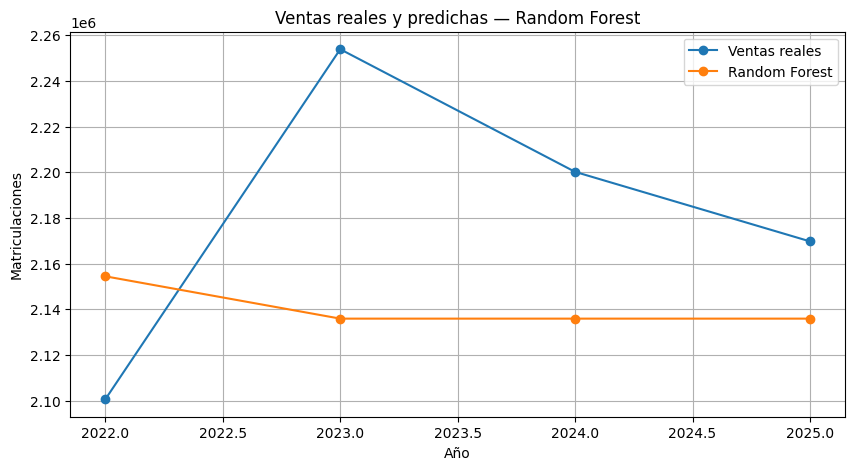

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    test["Year"],
    test["Ventas_BMW_Unidades"],
    marker="o",
    label="Ventas reales"
)

plt.plot(
    test["Year"],
    pred_test_cv,
    marker="o",
    label="Random Forest"
)

plt.xlabel("Año")
plt.ylabel("Matriculaciones")
plt.title("Ventas reales y predichas — Random Forest")
plt.legend()
plt.grid(True)
plt.show()

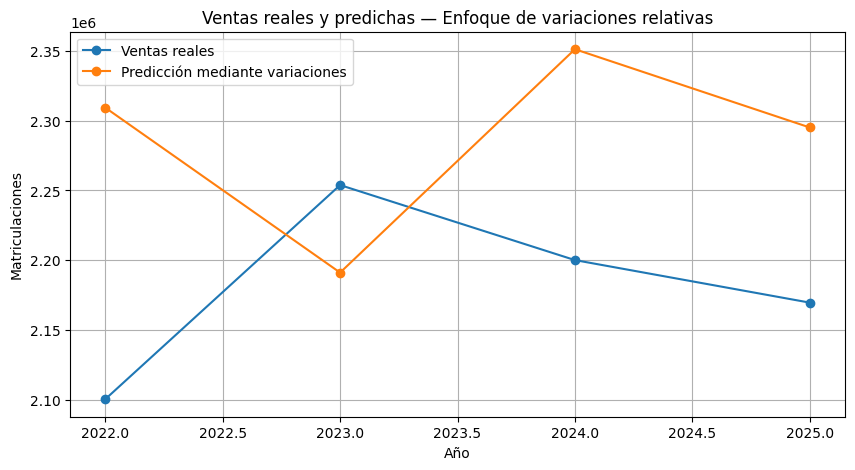

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    test_var_resultados["Year"],
    test_var_resultados["Ventas_BMW_Unidades"],
    marker="o",
    label="Ventas reales"
)

plt.plot(
    test_var_resultados["Year"],
    test_var_resultados["Prediccion_Ventas"],
    marker="o",
    label="Predicción mediante variaciones"
)

plt.xlabel("Año")
plt.ylabel("Matriculaciones")
plt.title(
    "Ventas reales y predichas — Enfoque de variaciones relativas"
)
plt.legend()
plt.grid(True)
plt.show()



---

# PARTE 35 — Error de las predicciones del Random Forest


---



Para analizar con mayor detalle el rendimiento del modelo, se calcula el error absoluto y el error porcentual de cada predicción en el conjunto de test.

| Año | Ventas reales | Predicción RF | Error | Error absoluto | Error porcentual |
|---:|---:|---:|---:|---:|---:|
| 2022 | 2.100.692 | 2.154.467,95 | -53.775,95 | 53.775,95 | 2,56 % |
| 2023 | 2.253.835 | 2.135.954,35 | 117.880,65 | 117.880,65 | 5,23 % |
| 2024 | 2.200.177 | 2.135.954,35 | 64.222,65 | 64.222,65 | 2,92 % |
| 2025 | 2.169.761 | 2.135.954,35 | 33.806,65 | 33.806,65 | 1,56 % |

El mayor error porcentual se produce en **2023 (5,23 %)**, mientras que el menor corresponde a **2025 (1,56 %)**. En conjunto, los errores se mantienen por debajo del 6 % en todos los años del periodo de test.

In [ ]:
predicciones_abs["Error_Porcentual"] = (
    predicciones_abs["Error"].abs()
    / predicciones_abs["Ventas_BMW_Unidades"]
) * 100

display(predicciones_abs)

,Year,Ventas_BMW_Unidades,Prediccion_RF,Error,Error_Absoluto,Error_Porcentual
17,2022,2100692,2154467.95,-53775.95,53775.95,2.559916
18,2023,2253835,2135954.35,117880.65,117880.65,5.230225
19,2024,2200177,2135954.35,64222.65,64222.65,2.918977
20,2025,2169761,2135954.35,33806.65,33806.65,1.558082




---


# PARTE 36 — Error de las predicciones mediante variaciones


---



Se calcula el error porcentual de las ventas reconstruidas a partir de las variaciones predichas por el modelo.

| Año | Ventas reales | Variación real | Variación predicha | Ventas año anterior | Ventas predichas | Error porcentual |
|---:|---:|---:|---:|---:|---:|---:|
| 2022 | 2.100.692 | -0,051090 | 0,043101 | 2.213.795 | 2.309.211 | 9,93 % |
| 2023 | 2.253.835 | 0,072901 | 0,043101 | 2.100.692 | 2.191.234 | 2,78 % |
| 2024 | 2.200.177 | -0,023807 | 0,043101 | 2.253.835 | 2.350.977 | 6,85 % |
| 2025 | 2.169.761 | -0,013824 | 0,043101 | 2.200.177 | 2.295.006 | 5,77 % |

El mayor error se produce en **2022 (9,93 %)**, debido principalmente a que el modelo predice un crecimiento del 4,31 %, mientras que las ventas reales disminuyen un 5,11 %. En los años posteriores, los errores son menores, aunque el modelo continúa mostrando dificultades para capturar las variaciones negativas de las ventas.

In [ ]:
test_var_resultados["Error_Porcentual"] = (
    (
        test_var_resultados["Ventas_BMW_Unidades"]
        - test_var_resultados["Prediccion_Ventas"]
    ).abs()
    / test_var_resultados["Ventas_BMW_Unidades"]
) * 100

display(test_var_resultados)

,Year,Ventas_BMW_Unidades,Ventas_BMW_Variacion,Prediccion_Variacion,Ventas_BMW_Año_Anterior,Prediccion_Ventas,Error_Porcentual
0,2022,2100692,-0.051090,0.043101,2213795,2.309211e+06,9.926223
1,2023,2253835,0.072901,0.043101,2100692,2.191234e+06,2.777553
2,2024,2200177,-0.023807,0.043101,2253835,2.350977e+06,6.854000
3,2025,2169761,-0.013824,0.043101,2200177,2.295006e+06,5.772315


In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score

# MAE del Random Forest
mae_rf = mean_absolute_error(
    y_test,
    pred_test_cv
)

# R² del Random Forest
r2_rf = r2_score(
    y_test,
    pred_test_cv
)

print(f"MAE Random Forest: {mae_rf:,.2f}")
print(f"R² Random Forest: {r2_rf:.4f}")

MAE Random Forest: 67,421.47
R² Random Forest: -0.8007


In [ ]:
mae_rf = mean_absolute_error(y_test, pred_test_cv)
rmse_rf = np.sqrt(mean_squared_error(y_test, pred_test_cv))
r2_rf = r2_score(y_test, pred_test_cv)

print(f"MAE:  {mae_rf:,.2f}")
print(f"RMSE: {rmse_rf:,.2f}")
print(f"R²:   {r2_rf:.4f}")

MAE:  67,421.47
RMSE: 74,254.86
R²:   -0.8007


---

# Conclusiones finales


---


En este cuaderno se han comparado dos formas diferentes de abordar la predicción de las ventas de BMW: **utilizando directamente las ventas absolutas** y **prediciendo las variaciones relativas interanuales**. Además, se han comparado dos estrategias de validación del Random Forest: una partición temporal fija y una validación mediante `TimeSeriesSplit`.

En primer lugar, el **baseline naive**, que utiliza las ventas del año anterior como predicción, sirve como referencia para determinar si los modelos de aprendizaje automático aportan una mejora real. En el conjunto de test obtiene un **MSE de 10.012.345.269,50** y un **RMSE de 100.061,71 matriculaciones**.

### Enfoque A: valores absolutos

Para el enfoque basado directamente en las ventas de BMW, el Random Forest con una partición temporal fija obtiene un **MSE de 12.114.233.109,67** y un **RMSE de 110.064,68**, por lo que **no supera al baseline naive**.

Sin embargo, al utilizar `TimeSeriesSplit` para seleccionar los hiperparámetros, el resultado mejora considerablemente. El modelo obtiene:

- **MSE:** 5.513.784.700,02
- **RMSE:** 74.254,86 matriculaciones

Esto supone una **reducción del MSE del 44,93 %** y una **reducción del RMSE del 25,79 % respecto al baseline**. Por tanto, este es el modelo que consigue las mejores predicciones en términos de ventas absolutas.

Las predicciones individuales muestran además que los errores porcentuales se mantienen relativamente bajos:

| Año | Ventas reales | Predicción RF | Error porcentual |
|---:|---:|---:|---:|
| 2022 | 2.100.692 | 2.154.467,95 | 2,56 % |
| 2023 | 2.253.835 | 2.135.954,35 | 5,23 % |
| 2024 | 2.200.177 | 2.135.954,35 | 2,92 % |
| 2025 | 2.169.761 | 2.135.954,35 | 1,56 % |

El mayor error se produce en **2023**, con un 5,23 %, mientras que en 2025 el error es únicamente del 1,56 %. Esto indica que el modelo consigue aproximarse razonablemente bien al nivel real de ventas, aunque presenta mayores dificultades para capturar cambios puntuales de la demanda.

### Enfoque B: variaciones relativas

En el segundo enfoque se predice la **variación porcentual de las ventas respecto al año anterior**. El baseline obtiene un RMSE de **0,106172**, mientras que el Random Forest con partición temporal alcanza **0,063330** y el modelo optimizado mediante `TimeSeriesSplit` obtiene **0,066101**.

En este caso, el modelo con partición temporal presenta ligeramente mejores resultados en el conjunto de test:

- **Baseline:** RMSE = 0,106172
- **Random Forest - partición temporal:** RMSE = 0,063330
- **Random Forest - TimeSeriesSplit:** RMSE = 0,066101

Tomando el modelo con `TimeSeriesSplit`, la reducción del RMSE respecto al baseline es del **37,74 %**, mientras que el MSE se reduce un **61,24 %**.

Sin embargo, existe una diferencia importante entre evaluar las variaciones y evaluar las ventas reconstruidas. Al transformar las variaciones predichas nuevamente en matriculaciones, el modelo obtiene un **RMSE de 146.480,69 matriculaciones**, frente a **231.918,34** del baseline reconstruido. Por tanto, aunque también mejora respecto a su referencia, su precisión final en términos de unidades vendidas es inferior a la del enfoque A.

Además, las predicciones muestran una limitación clara: el modelo predice una variación del **4,31 % para todos los años del periodo de test**. Esto hace que tenga dificultades para reproducir las caídas reales de ventas, especialmente en 2022, cuando las ventas disminuyeron un 5,11 %. Como consecuencia, el error porcentual de las ventas reconstruidas alcanza el **9,93 % en 2022**.

### Comparación final

Los resultados globales pueden resumirse de la siguiente manera:

| Enfoque | Modelo | MSE test | RMSE test |
|---|---|---:|---:|
| Valores absolutos | Baseline naive | 10.012.345.269,50 | 100.061,71 |
| Valores absolutos | RF - partición temporal | 12.114.233.109,67 | 110.064,68 |
| **Valores absolutos** | **RF - TimeSeriesSplit** | **5.513.784.700,02** | **74.254,86** |
| Variaciones relativas | Baseline naive | 0,011272 | 0,106172 |
| Variaciones relativas | RF - partición temporal | 0,004011 | 0,063330 |
| Variaciones relativas | RF - TimeSeriesSplit | 0,004369 | 0,066101 |

Por tanto, **el mejor resultado del estudio corresponde al Random Forest basado en valores absolutos y optimizado mediante `TimeSeriesSplit`**. Su RMSE de **74.254,86 matriculaciones** representa una mejora considerable frente al baseline de **100.061,71 matriculaciones**. Además, es el único modelo que consigue mejorar claramente al baseline cuando las predicciones se evalúan directamente en unidades de ventas.

El enfoque de variaciones relativas también demuestra capacidad predictiva y consigue mejoras importantes frente a su baseline. Sin embargo, al reconstruir las ventas absolutas, su error es mayor. Esto sugiere que, para este conjunto de datos, **modelar directamente las ventas absolutas resulta más adecuado que modelar sus variaciones interanuales**.

En conclusión, el análisis demuestra que la elección del método de validación tiene un impacto importante en los resultados. La utilización de `TimeSeriesSplit` permite aprovechar mejor la información disponible respetando el orden temporal y evita seleccionar los hiperparámetros únicamente en función de una única partición de desarrollo. A pesar de ello, los resultados deben interpretarse con cautela, ya que se dispone únicamente de **21 observaciones anuales**, de las cuales solo cuatro pertenecen al conjunto de test. Por este motivo, las conclusiones obtenidas son indicativas y deberían contrastarse con nuevos datos en futuras actualizaciones del modelo.